# MMPF vs Single RBPF Comparison

Visualize volatility tracking performance from test_mmpf_comparison output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
single = pd.read_csv('single_rbpf.csv')
mmpf = pd.read_csv('mmpf_full.csv')

print(f"Single RBPF: {len(single)} ticks")
print(f"MMPF Full: {len(mmpf)} ticks")
print(f"\nColumns: {list(single.columns)}")

Single RBPF: 8000 ticks
MMPF Full: 8000 ticks

Columns: ['tick', 'true_log_vol', 'true_vol', 'true_hypo', 'return', 'is_outlier', 'outlier_sigma', 'est_log_vol', 'est_vol', 'vol_std', 'est_hypo', 'weight_calm', 'weight_trend', 'weight_crisis', 'ess', 'min_weight', 'outlier_frac', 'learned_mu', 'learned_sigma', 'latency_us']


## Scenario Boundaries

In [2]:
# Scenario boundaries (from test code)
scenarios = {
    'Extended Calm': (0, 1500),
    'Slow Trend': (1500, 2500),
    'Sudden Crisis': (2500, 3000),
    'Crisis Persist': (3000, 4000),
    'Recovery': (4000, 5200),
    'Flash Crash': (5200, 5700),
    'Choppy': (5700, 8000)
}

# Colors for hypotheses
hypo_colors = {0: 'green', 1: 'orange', 2: 'red'}
hypo_names = {0: 'CALM', 1: 'TREND', 2: 'CRISIS'}

## Log-Volatility Tracking: Side by Side

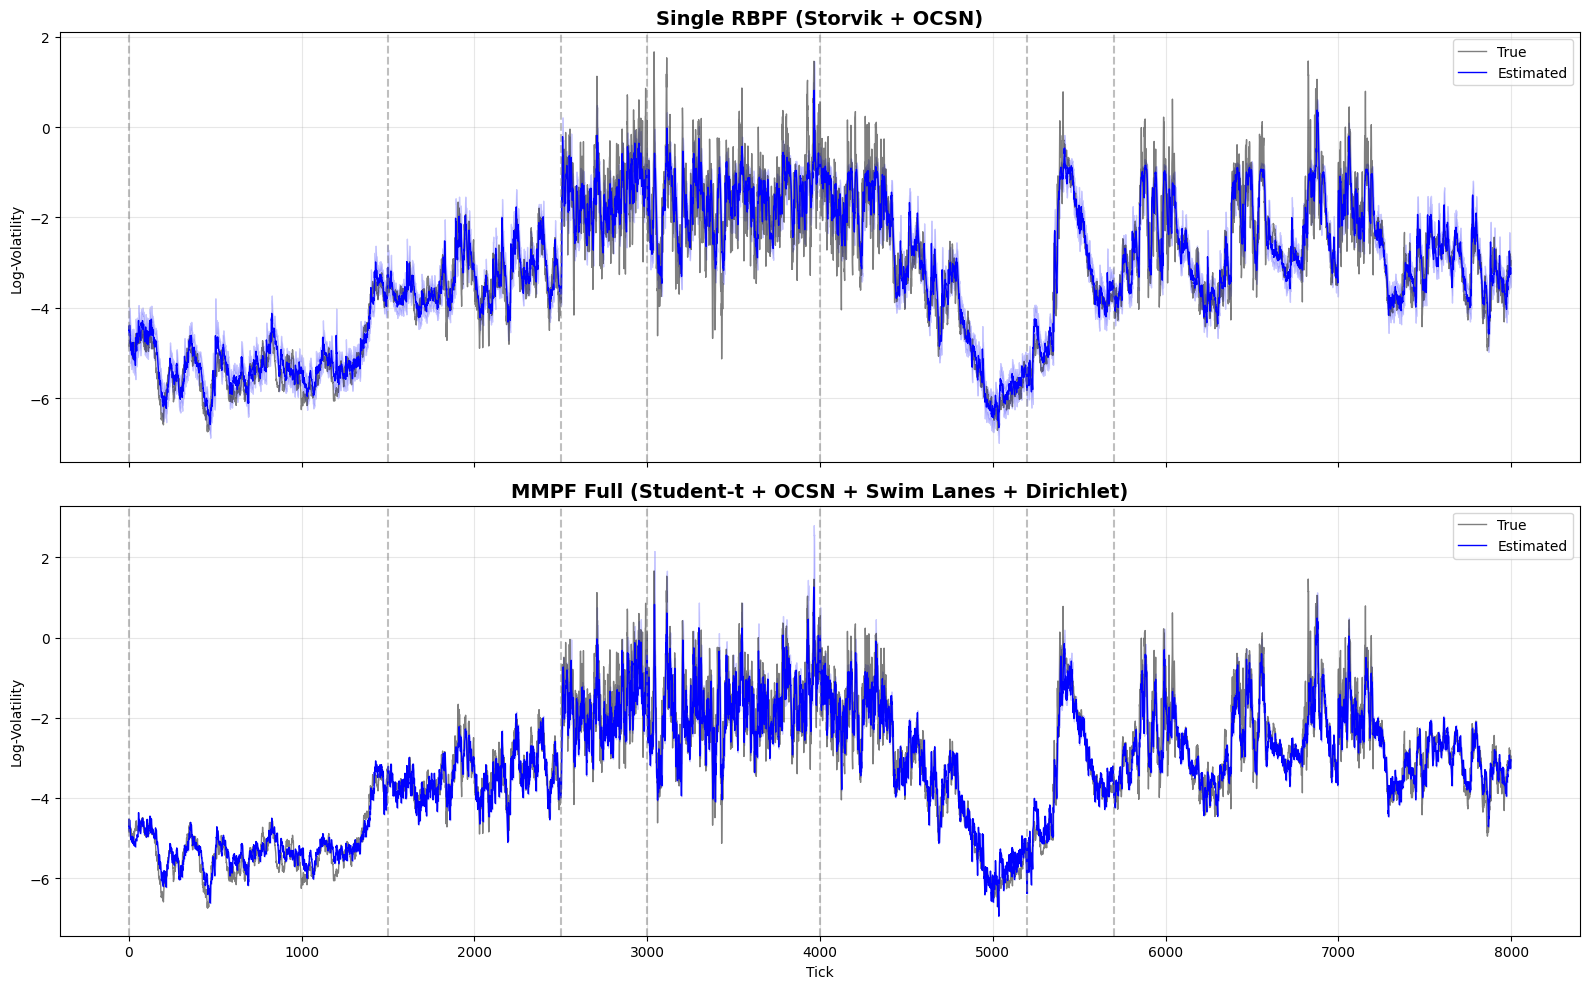

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Single RBPF
ax = axes[0]
ax.plot(single['tick'], single['true_log_vol'], 'k-', alpha=0.5, lw=1, label='True')
ax.plot(single['tick'], single['est_log_vol'], 'b-', lw=1, label='Estimated')
ax.fill_between(single['tick'], 
                single['est_log_vol'] - single['vol_std'],
                single['est_log_vol'] + single['vol_std'],
                alpha=0.2, color='blue')
ax.set_ylabel('Log-Volatility')
ax.set_title('Single RBPF (Storvik + OCSN)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Add scenario boundaries
for name, (start, end) in scenarios.items():
    ax.axvline(start, color='gray', linestyle='--', alpha=0.5)

# MMPF
ax = axes[1]
ax.plot(mmpf['tick'], mmpf['true_log_vol'], 'k-', alpha=0.5, lw=1, label='True')
ax.plot(mmpf['tick'], mmpf['est_log_vol'], 'b-', lw=1, label='Estimated')
ax.fill_between(mmpf['tick'], 
                mmpf['est_log_vol'] - mmpf['vol_std'],
                mmpf['est_log_vol'] + mmpf['vol_std'],
                alpha=0.2, color='blue')
ax.set_ylabel('Log-Volatility')
ax.set_xlabel('Tick')
ax.set_title('MMPF Full (Student-t + OCSN + Swim Lanes + Dirichlet)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Add scenario boundaries
for name, (start, end) in scenarios.items():
    ax.axvline(start, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('log_vol_comparison.png', dpi=150)
plt.show()

## Tracking Error Over Time

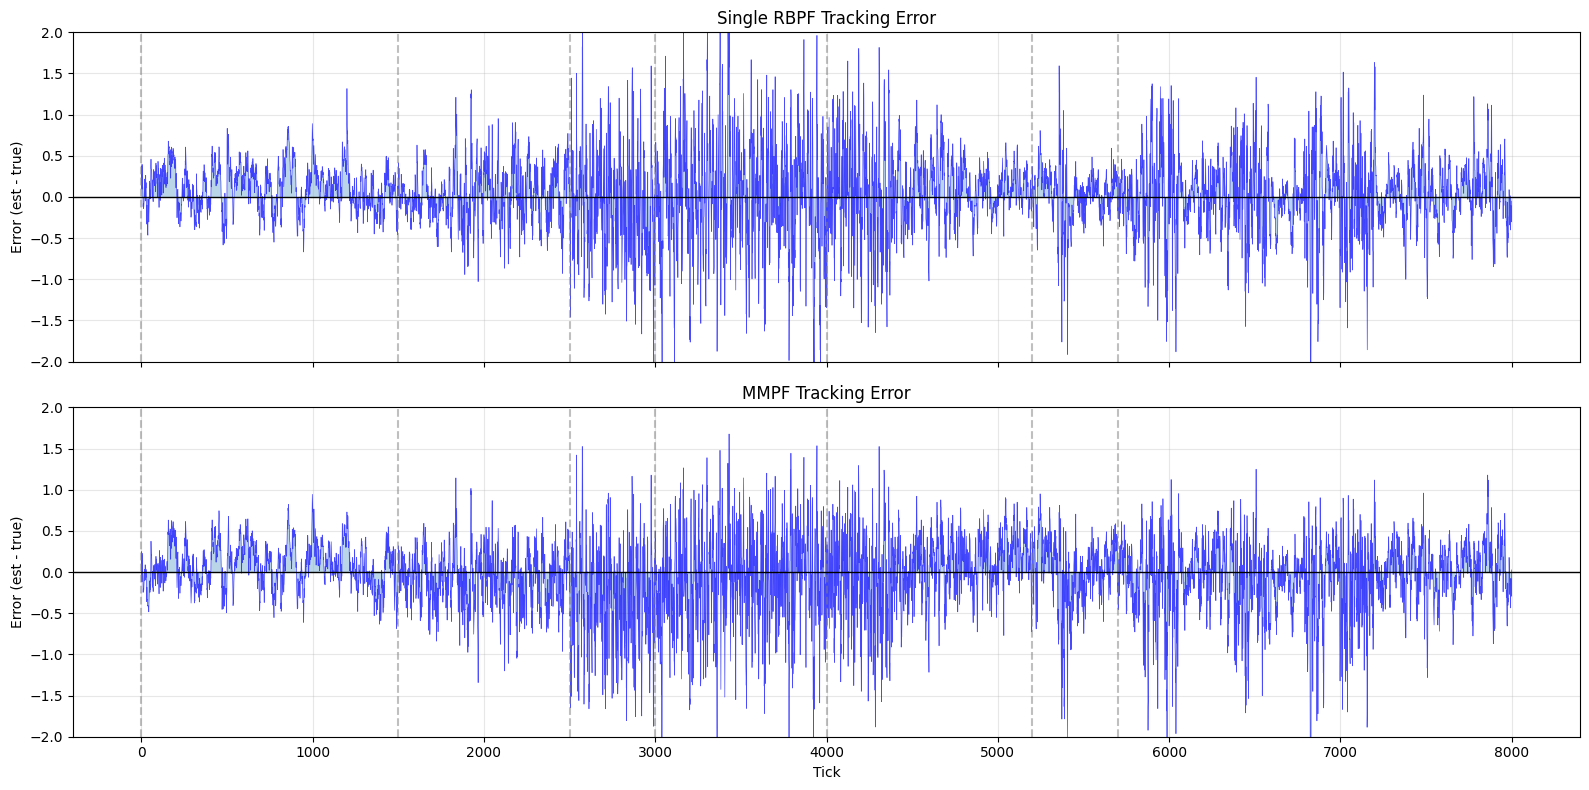

In [4]:
# Compute tracking errors
single['error'] = single['est_log_vol'] - single['true_log_vol']
mmpf['error'] = mmpf['est_log_vol'] - mmpf['true_log_vol']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Single RBPF error
ax = axes[0]
ax.plot(single['tick'], single['error'], 'b-', lw=0.5, alpha=0.7)
ax.axhline(0, color='k', linestyle='-', lw=1)
ax.fill_between(single['tick'], single['error'], 0, alpha=0.3)
ax.set_ylabel('Error (est - true)')
ax.set_title('Single RBPF Tracking Error', fontsize=12)
ax.set_ylim(-2, 2)
ax.grid(True, alpha=0.3)

for name, (start, end) in scenarios.items():
    ax.axvline(start, color='gray', linestyle='--', alpha=0.5)

# MMPF error
ax = axes[1]
ax.plot(mmpf['tick'], mmpf['error'], 'b-', lw=0.5, alpha=0.7)
ax.axhline(0, color='k', linestyle='-', lw=1)
ax.fill_between(mmpf['tick'], mmpf['error'], 0, alpha=0.3)
ax.set_ylabel('Error (est - true)')
ax.set_xlabel('Tick')
ax.set_title('MMPF Tracking Error', fontsize=12)
ax.set_ylim(-2, 2)
ax.grid(True, alpha=0.3)

for name, (start, end) in scenarios.items():
    ax.axvline(start, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('tracking_error.png', dpi=150)
plt.show()

## Hypothesis/Regime Detection

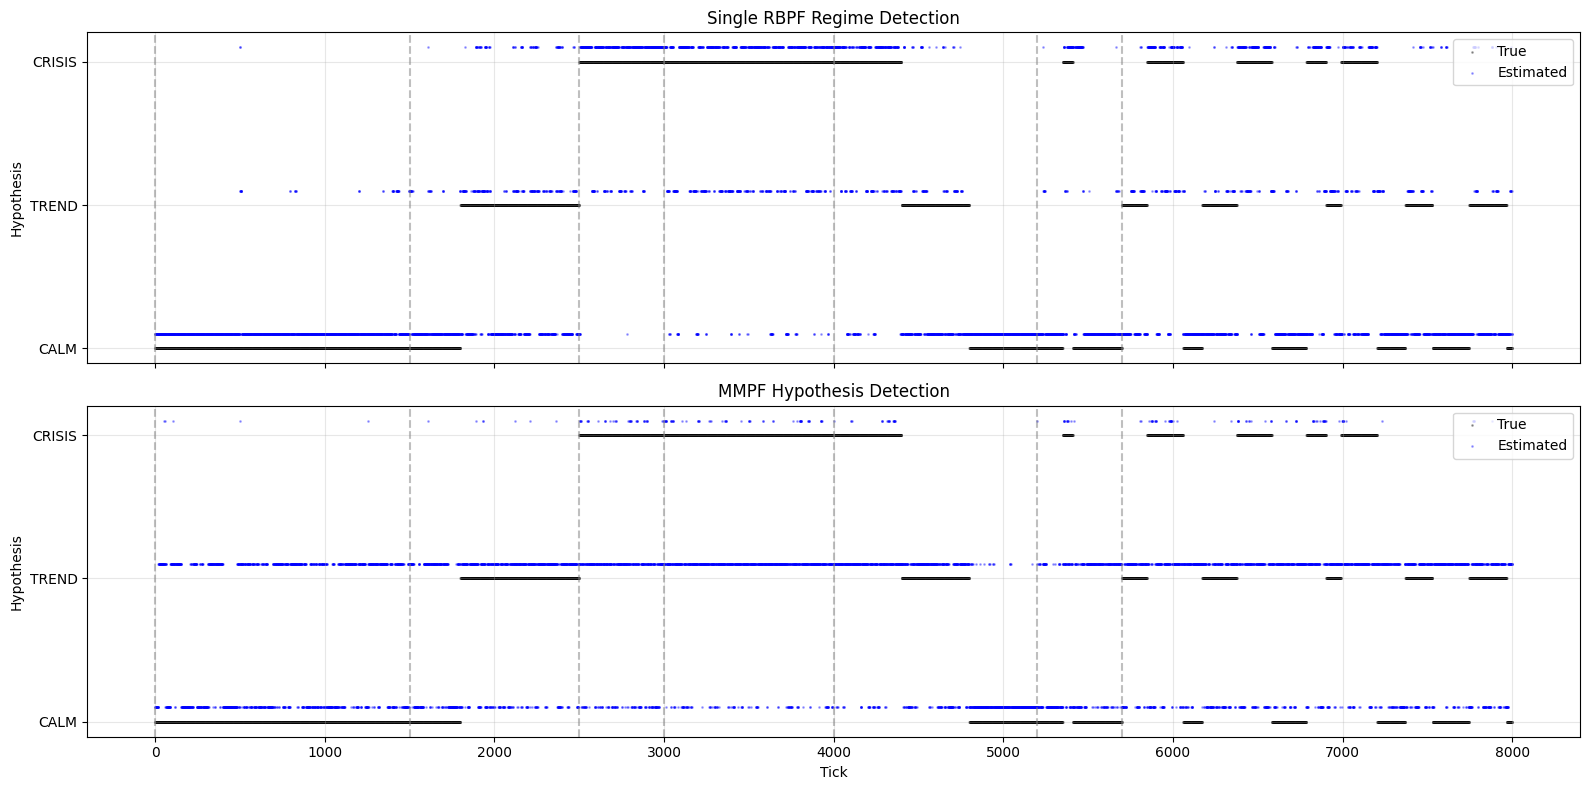

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Single RBPF
ax = axes[0]
ax.scatter(single['tick'], single['true_hypo'], c='black', s=1, alpha=0.3, label='True')
ax.scatter(single['tick'], single['est_hypo'] + 0.1, c='blue', s=1, alpha=0.3, label='Estimated')
ax.set_ylabel('Hypothesis')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['CALM', 'TREND', 'CRISIS'])
ax.set_title('Single RBPF Regime Detection', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

for name, (start, end) in scenarios.items():
    ax.axvline(start, color='gray', linestyle='--', alpha=0.5)

# MMPF
ax = axes[1]
ax.scatter(mmpf['tick'], mmpf['true_hypo'], c='black', s=1, alpha=0.3, label='True')
ax.scatter(mmpf['tick'], mmpf['est_hypo'] + 0.1, c='blue', s=1, alpha=0.3, label='Estimated')
ax.set_ylabel('Hypothesis')
ax.set_xlabel('Tick')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['CALM', 'TREND', 'CRISIS'])
ax.set_title('MMPF Hypothesis Detection', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

for name, (start, end) in scenarios.items():
    ax.axvline(start, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('regime_detection.png', dpi=150)
plt.show()

## MMPF Hypothesis Weights

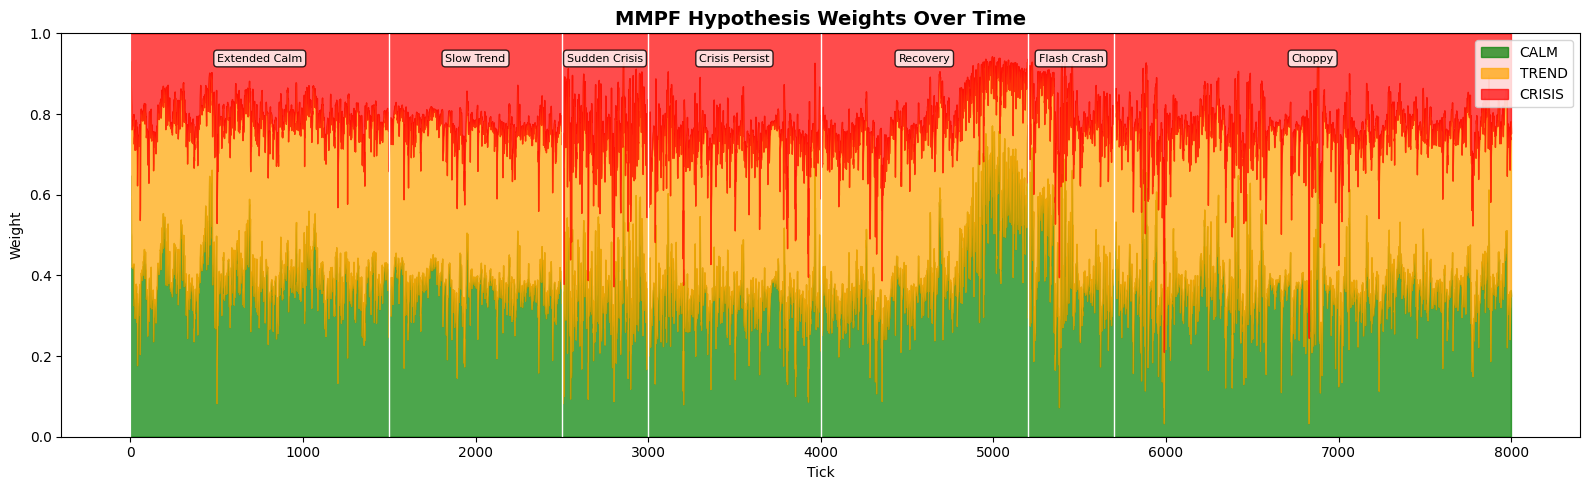

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(mmpf['tick'], 0, mmpf['weight_calm'], 
                alpha=0.7, color='green', label='CALM')
ax.fill_between(mmpf['tick'], mmpf['weight_calm'], 
                mmpf['weight_calm'] + mmpf['weight_trend'],
                alpha=0.7, color='orange', label='TREND')
ax.fill_between(mmpf['tick'], mmpf['weight_calm'] + mmpf['weight_trend'], 1,
                alpha=0.7, color='red', label='CRISIS')

ax.set_ylabel('Weight')
ax.set_xlabel('Tick')
ax.set_title('MMPF Hypothesis Weights Over Time', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)

# Add scenario labels
for name, (start, end) in scenarios.items():
    ax.axvline(start, color='white', linestyle='-', lw=1)
    mid = (start + end) / 2
    ax.text(mid, 0.95, name, ha='center', va='top', fontsize=8, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('mmpf_weights.png', dpi=150)
plt.show()

## ESS Comparison

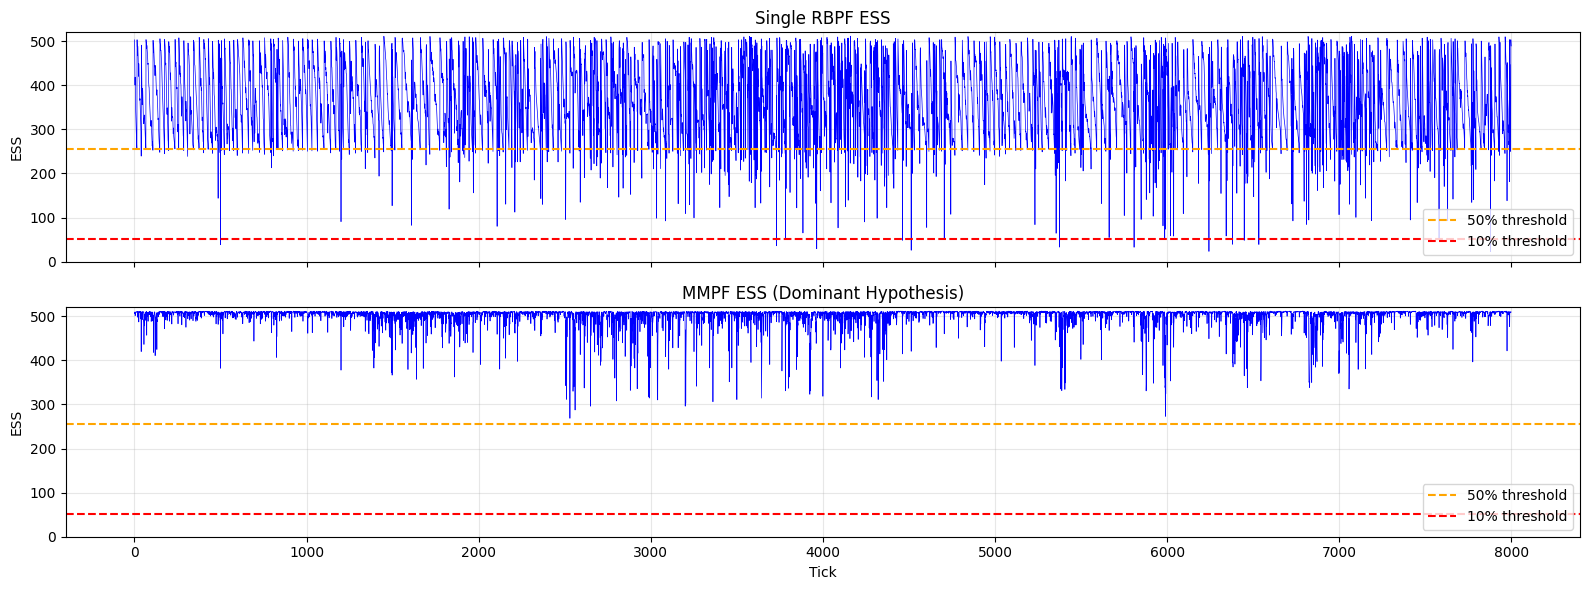

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

ax = axes[0]
ax.plot(single['tick'], single['ess'], 'b-', lw=0.5)
ax.axhline(512 * 0.5, color='orange', linestyle='--', label='50% threshold')
ax.axhline(512 * 0.1, color='red', linestyle='--', label='10% threshold')
ax.set_ylabel('ESS')
ax.set_title('Single RBPF ESS', fontsize=12)
ax.set_ylim(0, 520)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(mmpf['tick'], mmpf['ess'], 'b-', lw=0.5)
ax.axhline(512 * 0.5, color='orange', linestyle='--', label='50% threshold')
ax.axhline(512 * 0.1, color='red', linestyle='--', label='10% threshold')
ax.set_ylabel('ESS')
ax.set_xlabel('Tick')
ax.set_title('MMPF ESS (Dominant Hypothesis)', fontsize=12)
ax.set_ylim(0, 520)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ess_comparison.png', dpi=150)
plt.show()

## Zoom: Crisis Period (Sudden Crisis + Crisis Persist)

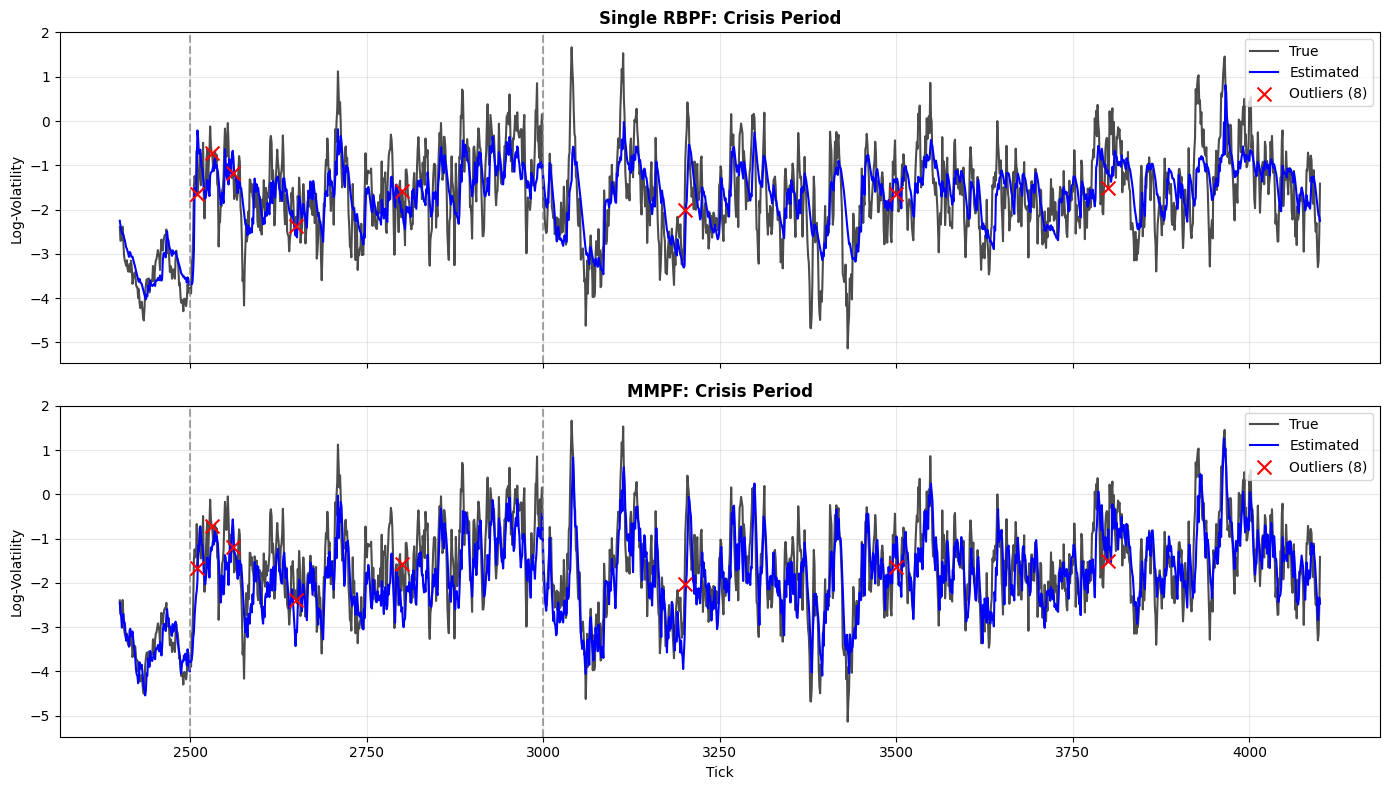

In [8]:
crisis_start, crisis_end = 2400, 4100

single_crisis = single[(single['tick'] >= crisis_start) & (single['tick'] <= crisis_end)]
mmpf_crisis = mmpf[(mmpf['tick'] >= crisis_start) & (mmpf['tick'] <= crisis_end)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Single RBPF
ax = axes[0]
ax.plot(single_crisis['tick'], single_crisis['true_log_vol'], 'k-', lw=1.5, label='True', alpha=0.7)
ax.plot(single_crisis['tick'], single_crisis['est_log_vol'], 'b-', lw=1.5, label='Estimated')

# Mark outliers
outliers = single_crisis[single_crisis['is_outlier'] == 1]
ax.scatter(outliers['tick'], outliers['true_log_vol'], c='red', s=100, marker='x', 
           zorder=5, label=f'Outliers ({len(outliers)})')

ax.set_ylabel('Log-Volatility')
ax.set_title('Single RBPF: Crisis Period', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.axvline(2500, color='gray', linestyle='--', alpha=0.7)
ax.axvline(3000, color='gray', linestyle='--', alpha=0.7)

# MMPF
ax = axes[1]
ax.plot(mmpf_crisis['tick'], mmpf_crisis['true_log_vol'], 'k-', lw=1.5, label='True', alpha=0.7)
ax.plot(mmpf_crisis['tick'], mmpf_crisis['est_log_vol'], 'b-', lw=1.5, label='Estimated')

# Mark outliers
outliers = mmpf_crisis[mmpf_crisis['is_outlier'] == 1]
ax.scatter(outliers['tick'], outliers['true_log_vol'], c='red', s=100, marker='x', 
           zorder=5, label=f'Outliers ({len(outliers)})')

ax.set_ylabel('Log-Volatility')
ax.set_xlabel('Tick')
ax.set_title('MMPF: Crisis Period', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.axvline(2500, color='gray', linestyle='--', alpha=0.7)
ax.axvline(3000, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('crisis_zoom.png', dpi=150)
plt.show()

## Zoom: Flash Crash

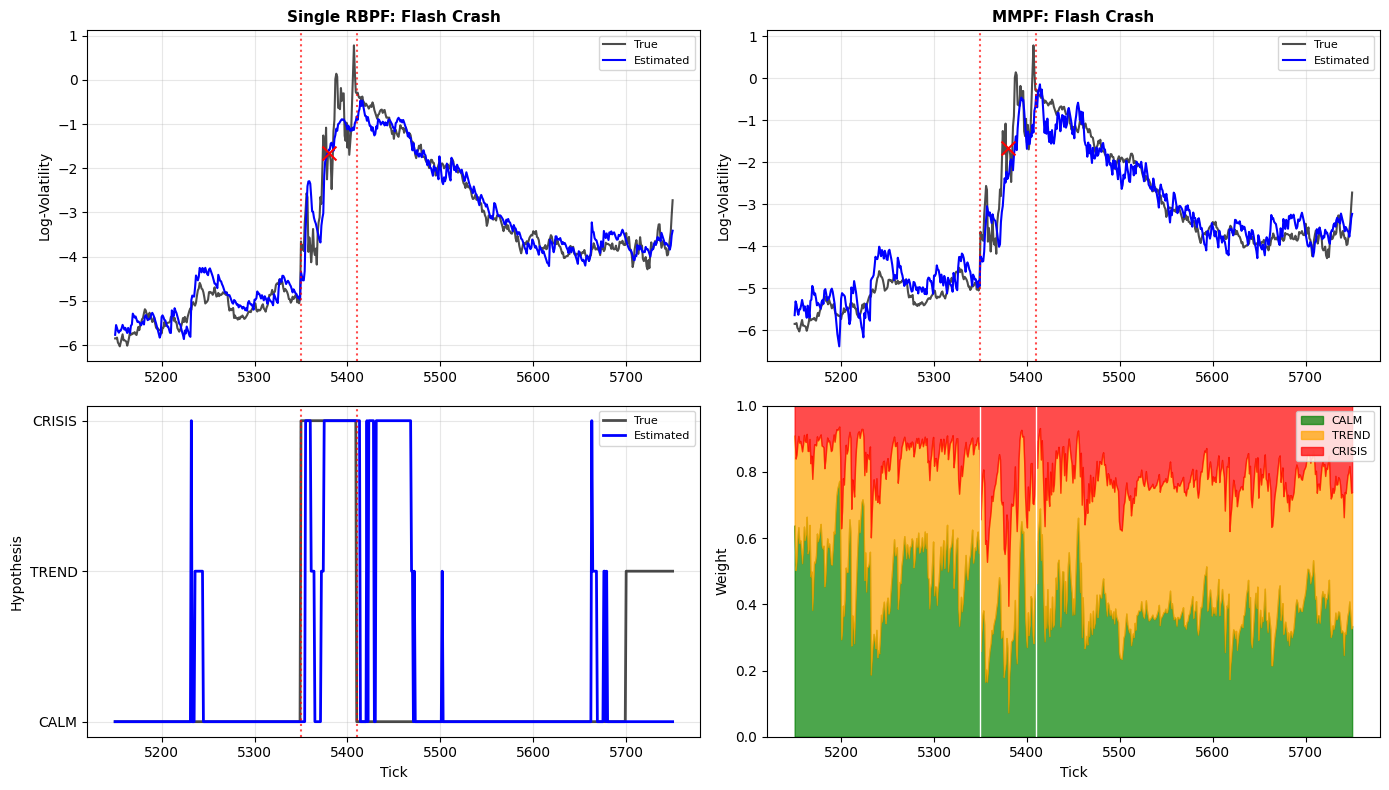

In [9]:
flash_start, flash_end = 5150, 5750

single_flash = single[(single['tick'] >= flash_start) & (single['tick'] <= flash_end)]
mmpf_flash = mmpf[(mmpf['tick'] >= flash_start) & (mmpf['tick'] <= flash_end)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Single RBPF - Log Vol
ax = axes[0, 0]
ax.plot(single_flash['tick'], single_flash['true_log_vol'], 'k-', lw=1.5, label='True', alpha=0.7)
ax.plot(single_flash['tick'], single_flash['est_log_vol'], 'b-', lw=1.5, label='Estimated')
outliers = single_flash[single_flash['is_outlier'] == 1]
ax.scatter(outliers['tick'], outliers['true_log_vol'], c='red', s=100, marker='x', zorder=5)
ax.set_ylabel('Log-Volatility')
ax.set_title('Single RBPF: Flash Crash', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.axvline(5350, color='red', linestyle=':', alpha=0.7)
ax.axvline(5410, color='red', linestyle=':', alpha=0.7)

# Single RBPF - Hypothesis
ax = axes[1, 0]
ax.plot(single_flash['tick'], single_flash['true_hypo'], 'k-', lw=2, label='True', alpha=0.7)
ax.plot(single_flash['tick'], single_flash['est_hypo'], 'b-', lw=2, label='Estimated')
ax.set_ylabel('Hypothesis')
ax.set_xlabel('Tick')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['CALM', 'TREND', 'CRISIS'])
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.axvline(5350, color='red', linestyle=':', alpha=0.7)
ax.axvline(5410, color='red', linestyle=':', alpha=0.7)

# MMPF - Log Vol
ax = axes[0, 1]
ax.plot(mmpf_flash['tick'], mmpf_flash['true_log_vol'], 'k-', lw=1.5, label='True', alpha=0.7)
ax.plot(mmpf_flash['tick'], mmpf_flash['est_log_vol'], 'b-', lw=1.5, label='Estimated')
outliers = mmpf_flash[mmpf_flash['is_outlier'] == 1]
ax.scatter(outliers['tick'], outliers['true_log_vol'], c='red', s=100, marker='x', zorder=5)
ax.set_ylabel('Log-Volatility')
ax.set_title('MMPF: Flash Crash', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.axvline(5350, color='red', linestyle=':', alpha=0.7)
ax.axvline(5410, color='red', linestyle=':', alpha=0.7)

# MMPF - Weights
ax = axes[1, 1]
ax.fill_between(mmpf_flash['tick'], 0, mmpf_flash['weight_calm'], 
                alpha=0.7, color='green', label='CALM')
ax.fill_between(mmpf_flash['tick'], mmpf_flash['weight_calm'], 
                mmpf_flash['weight_calm'] + mmpf_flash['weight_trend'],
                alpha=0.7, color='orange', label='TREND')
ax.fill_between(mmpf_flash['tick'], mmpf_flash['weight_calm'] + mmpf_flash['weight_trend'], 1,
                alpha=0.7, color='red', label='CRISIS')
ax.set_ylabel('Weight')
ax.set_xlabel('Tick')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=8)
ax.axvline(5350, color='white', linestyle='-', lw=1)
ax.axvline(5410, color='white', linestyle='-', lw=1)

plt.tight_layout()
plt.savefig('flash_crash_zoom.png', dpi=150)
plt.show()

## Per-Scenario RMSE

      Scenario  Single RBPF     MMPF  Improvement
 Extended Calm     0.291524 0.280873     3.653332
    Slow Trend     0.350579 0.350160     0.119499
 Sudden Crisis     0.657492 0.712020    -8.293369
Crisis Persist     0.747978 0.624452    16.514612
      Recovery     0.482243 0.453378     5.985520
   Flash Crash     0.360460 0.424479   -17.760263
        Choppy     0.466742 0.469169    -0.519884


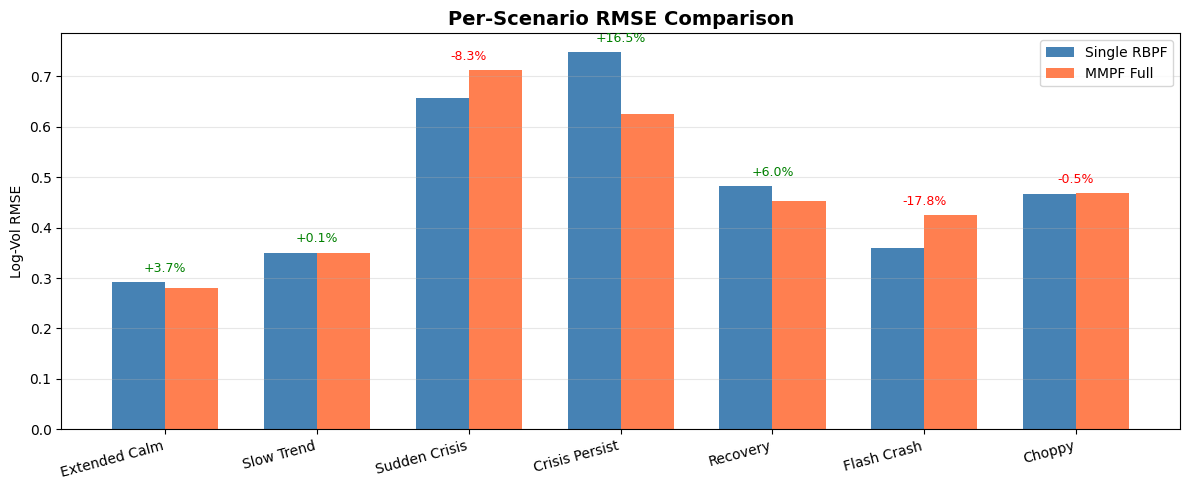

In [10]:
def compute_rmse(df, start, end):
    subset = df[(df['tick'] >= start) & (df['tick'] < end)]
    error = subset['est_log_vol'] - subset['true_log_vol']
    return np.sqrt((error ** 2).mean())

scenario_rmse = []
for name, (start, end) in scenarios.items():
    single_rmse = compute_rmse(single, start, end)
    mmpf_rmse = compute_rmse(mmpf, start, end)
    improvement = (single_rmse - mmpf_rmse) / single_rmse * 100
    scenario_rmse.append({
        'Scenario': name,
        'Single RBPF': single_rmse,
        'MMPF': mmpf_rmse,
        'Improvement': improvement
    })

rmse_df = pd.DataFrame(scenario_rmse)
print(rmse_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rmse_df))
width = 0.35

bars1 = ax.bar(x - width/2, rmse_df['Single RBPF'], width, label='Single RBPF', color='steelblue')
bars2 = ax.bar(x + width/2, rmse_df['MMPF'], width, label='MMPF Full', color='coral')

ax.set_ylabel('Log-Vol RMSE')
ax.set_title('Per-Scenario RMSE Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(rmse_df['Scenario'], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add improvement labels
for i, (s, m, imp) in enumerate(zip(rmse_df['Single RBPF'], rmse_df['MMPF'], rmse_df['Improvement'])):
    color = 'green' if imp > 0 else 'red'
    ax.annotate(f'{imp:+.1f}%', xy=(i, max(s, m) + 0.02), ha='center', fontsize=9, color=color)

plt.tight_layout()
plt.savefig('rmse_by_scenario.png', dpi=150)
plt.show()

## Outlier Detection

In [11]:
# Get outlier ticks
outlier_ticks = single[single['is_outlier'] == 1]['tick'].values

print(f"Outlier ticks: {outlier_ticks}")
print(f"\nOutlier Analysis:")
print("-" * 80)

for tick in outlier_ticks:
    s = single[single['tick'] == tick].iloc[0]
    m = mmpf[mmpf['tick'] == tick].iloc[0]
    
    print(f"\nTick {tick} ({s['outlier_sigma']:.0f}σ outlier):")
    print(f"  True hypothesis: {hypo_names[int(s['true_hypo'])]}")
    print(f"  Single RBPF: est_hypo={hypo_names[int(s['est_hypo'])]}, outlier_frac={s['outlier_frac']:.2f}")
    print(f"  MMPF:        est_hypo={hypo_names[int(m['est_hypo'])]}, outlier_frac={m['outlier_frac']:.2f}")
    print(f"  Single error: {abs(s['est_log_vol'] - s['true_log_vol']):.3f}")
    print(f"  MMPF error:   {abs(m['est_log_vol'] - m['true_log_vol']):.3f}")

Outlier ticks: [ 500 1200 2510 2530 2560 2650 2800 3200 3500 3800 5380]

Outlier Analysis:
--------------------------------------------------------------------------------

Tick 500 (6σ outlier):
  True hypothesis: CALM
  Single RBPF: est_hypo=CRISIS, outlier_frac=0.43
  MMPF:        est_hypo=CRISIS, outlier_frac=0.96
  Single error: 0.684
  MMPF error:   0.035

Tick 1200 (8σ outlier):
  True hypothesis: CALM
  Single RBPF: est_hypo=TREND, outlier_frac=0.23
  MMPF:        est_hypo=TREND, outlier_frac=0.54
  Single error: 1.317
  MMPF error:   0.730

Tick 2510 (8σ outlier):
  True hypothesis: CRISIS
  Single RBPF: est_hypo=CRISIS, outlier_frac=0.09
  MMPF:        est_hypo=CRISIS, outlier_frac=0.87
  Single error: 1.444
  MMPF error:   0.288

Tick 2530 (10σ outlier):
  True hypothesis: CRISIS
  Single RBPF: est_hypo=CRISIS, outlier_frac=1.00
  MMPF:        est_hypo=TREND, outlier_frac=1.00
  Single error: 0.439
  MMPF error:   0.553

Tick 2560 (12σ outlier):
  True hypothesis: CRISIS
  S

## Minimum Hypothesis Weight (Dirichlet Check)

Min weight statistics:
  Mean: 0.2212
  Min:  0.0329
  Max:  0.3190


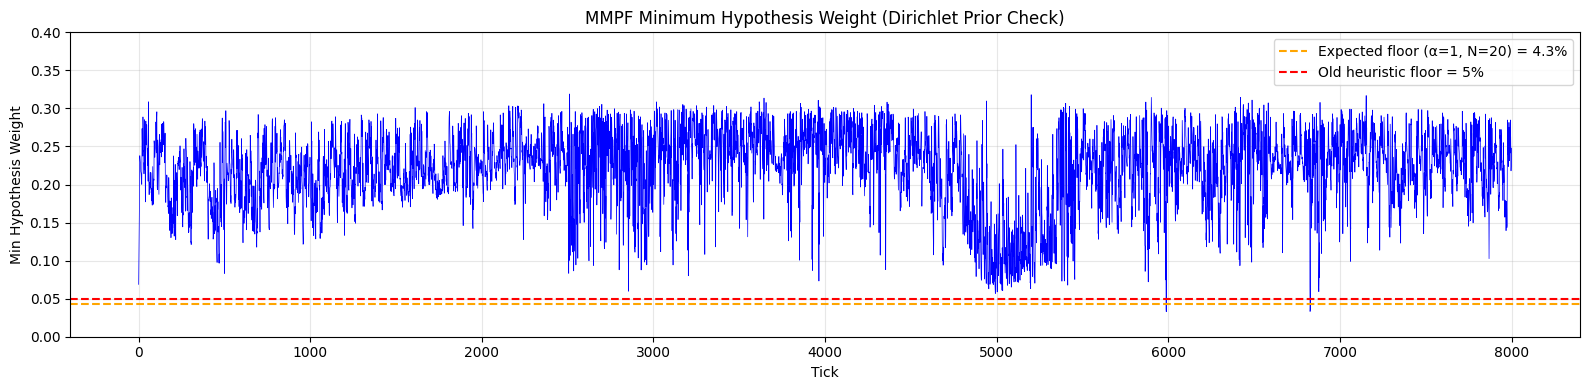

In [12]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(mmpf['tick'], mmpf['min_weight'], 'b-', lw=0.5)
ax.axhline(0.043, color='orange', linestyle='--', label='Expected floor (α=1, N=20) = 4.3%')
ax.axhline(0.05, color='red', linestyle='--', label='Old heuristic floor = 5%')

ax.set_ylabel('Min Hypothesis Weight')
ax.set_xlabel('Tick')
ax.set_title('MMPF Minimum Hypothesis Weight (Dirichlet Prior Check)', fontsize=12)
ax.legend(loc='upper right')
ax.set_ylim(0, 0.4)
ax.grid(True, alpha=0.3)

print(f"Min weight statistics:")
print(f"  Mean: {mmpf['min_weight'].mean():.4f}")
print(f"  Min:  {mmpf['min_weight'].min():.4f}")
print(f"  Max:  {mmpf['min_weight'].max():.4f}")

plt.tight_layout()
plt.savefig('dirichlet_check.png', dpi=150)
plt.show()

## Summary Statistics

In [13]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

# Log-vol RMSE
single_rmse = np.sqrt(((single['est_log_vol'] - single['true_log_vol']) ** 2).mean())
mmpf_rmse = np.sqrt(((mmpf['est_log_vol'] - mmpf['true_log_vol']) ** 2).mean())
print(f"\nLog-Vol RMSE:")
print(f"  Single RBPF: {single_rmse:.4f}")
print(f"  MMPF:        {mmpf_rmse:.4f}")
print(f"  Improvement: {(single_rmse - mmpf_rmse) / single_rmse * 100:.1f}%")

# Hypothesis accuracy
single_acc = (single['est_hypo'] == single['true_hypo']).mean()
mmpf_acc = (mmpf['est_hypo'] == mmpf['true_hypo']).mean()
print(f"\nHypothesis Accuracy:")
print(f"  Single RBPF: {single_acc:.1%}")
print(f"  MMPF:        {mmpf_acc:.1%}")

# ESS
print(f"\nESS:")
print(f"  Single RBPF: mean={single['ess'].mean():.1f}, min={single['ess'].min():.1f}")
print(f"  MMPF:        mean={mmpf['ess'].mean():.1f}, min={mmpf['ess'].min():.1f}")

# Outlier handling
print(f"\nOutlier Fraction (on outlier ticks):")
single_outliers = single[single['is_outlier'] == 1]['outlier_frac'].mean()
mmpf_outliers = mmpf[mmpf['is_outlier'] == 1]['outlier_frac'].mean()
print(f"  Single RBPF: {single_outliers:.2f}")
print(f"  MMPF:        {mmpf_outliers:.2f}")

# Latency
print(f"\nLatency (us):")
print(f"  Single RBPF: median={single['latency_us'].median():.1f}, p99={single['latency_us'].quantile(0.99):.1f}")
print(f"  MMPF:        median={mmpf['latency_us'].median():.1f}, p99={mmpf['latency_us'].quantile(0.99):.1f}")

SUMMARY STATISTICS

Log-Vol RMSE:
  Single RBPF: 0.4836
  MMPF:        0.4647
  Improvement: 3.9%

Hypothesis Accuracy:
  Single RBPF: 66.3%
  MMPF:        38.7%

ESS:
  Single RBPF: mean=369.9, min=22.5
  MMPF:        mean=501.2, min=268.6

Outlier Fraction (on outlier ticks):
  Single RBPF: 0.78
  MMPF:        0.88

Latency (us):
  Single RBPF: median=41.8, p99=107.2
  MMPF:        median=160.9, p99=260.8
